# Ficheiro 1 - Atividade de Internamento Hospitalar

## Análise da demória média de internamento por região
User story 1:
"Como gestor de uma unidade hospitalar, quero ver a demora média de internamento da minha região comparada com as restantes regiões de saúde."

In [6]:
import sqlite3
import pandas as pd

df = pd.read_csv("../data/processed/atividade_de_internamento_tratado.csv", sep=",", encoding="utf-8-sig")

# Liga (ou cria) a base de dados SQLite
con = sqlite3.connect("../data/processed/internamento-hospital.db")

# df.to_sql escreve o DataFrame como uma TABELA dentro da base de dados.
# if_exists='replace' substitui a tabela se já existir; index=False não guarda o nº da linha.

df.to_sql("internamento", con, if_exists="replace", index=False)


q = """

SELECT regiao,        
ROUND(SUM(dias_internamento) / SUM(doentes_saidos)) AS demora_media_regiao
FROM internamento
WHERE doentes_saidos > 0
GROUP BY regiao
ORDER BY demora_media_regiao DESC;

"""
print(" ")
print("Demora média por região:")

display(pd.read_sql(q, con))



 
Demora média por região:


,regiao,demora_media_regiao
0,Região de Saúde do Algarve,10.0
1,Região de Saúde LVT,9.0
2,Região de Saúde do Norte,8.0
3,Região de Saúde do Centro,8.0
4,Região de Saúde do Alentejo,8.0


## Conclusão:
O Algarve apresenta a maior demora média de internamento (10 dias), seguido de Lisboa e Vale do Tejo (9 dias). As restantes regiões registam uma média de 8 dias. Estes resultados evidenciam diferenças regionais na duração dos internamentos, que poderão justificar uma análise mais detalhada dos fatores condicionantes.

## Análise da evolução anual da demora média de internamento
User story 2:
"Como responsável de planeamento da ACSS, quero ver a evolução dos dias de internamento ao longo do tempo (2015–2026), para perceber o impacto de eventos como a pandemia na capacidade hospitalar."

In [7]:
q = """

SELECT SUBSTR(periodo, 1, 4) AS ano,     
ROUND(SUM(dias_internamento) / SUM(doentes_saidos)) AS demora_media
FROM internamento
WHERE doentes_saidos > 0
GROUP BY ano
ORDER BY ano;
"""

print("Evolução anual da demora média:")
display(pd.read_sql(q, con))

Evolução anual da demora média:


,ano,demora_media
0,2015,8.0
1,2016,8.0
2,2017,8.0
3,2018,9.0
4,2019,9.0
5,2020,9.0
6,2021,9.0
7,2022,9.0
8,2023,9.0
9,2024,9.0


## Conclusão
A demora média de internamento aumentou de 8 para 9 dias em 2018 e manteve-se estável até 2026. Apesar de este período incluir a pandemia (COVID-19), os dados não evidenciam uma alteração específica em 2020, não sendo possível atribuir esta evolução ao impacto da pandemia.

# Análise da demora média de internamento por especialidade
User story 3:
"Como responsável clínico, quero ver a demora média por diagnóstico, faixa etária, sexo e especialidade, para perceber que perfil de doente ocupa mais dias de internamento."


Demora média por especialidade:
                         dias_internamento  doentes_saidos  demora_media
especialidade                                                           
Especialidade Cirurgica        175656966.0      27706307.0      6.339963
Especialidade Médica           265013357.0      25546291.0     10.373849
Outras Camas                    35620629.0       2275531.0     15.653766


<Axes: title={'center': 'Demora média por especialidade'}, xlabel='Especialidade', ylabel='Demora média (dias)'>

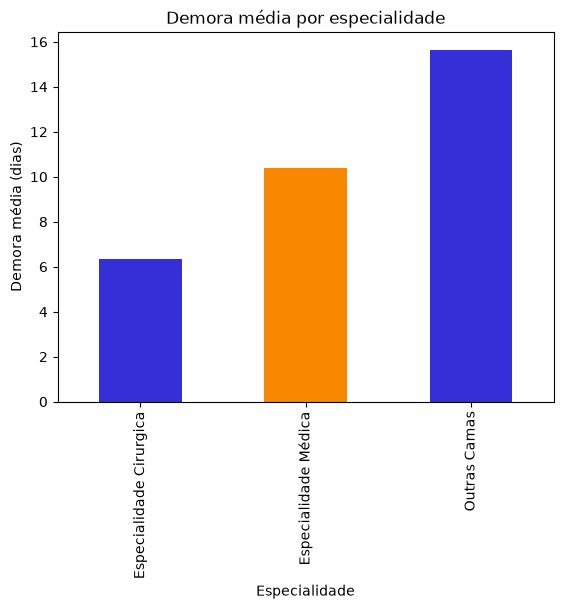

In [8]:
print("Demora média por especialidade:")
demora_especialidade = df.groupby("especialidade")[
    ["dias_internamento", "doentes_saidos"]
].sum()

demora_especialidade["demora_media"] = (
    demora_especialidade["dias_internamento"] /
    demora_especialidade["doentes_saidos"]
)

print(demora_especialidade)


demora_especialidade["demora_media"].plot(kind="bar", title="Demora média por especialidade", xlabel="Especialidade", ylabel="Demora média (dias)", color=["#352fd8", "#f78800"])


## Conclusão
A categoria "Outras Camas" apresenta a maior demora média de internamento, seguida da "Especialidade Médica" e da "Especialidade Cirúrgica". 
A categoria "Outras Camas" engloba internamentos que não estão associados a uma especialidade específica (internamentos de reabilitação, unidades de convalescença, cuidados paliativos, etc.), o que poderá justificar a demora média mais elevada.

## Análise de Correlações
Correlação entre o número de doentes saídos e o total de dias de internamento.

A correlação entre as duas varíaveis númericas é: 0.9345


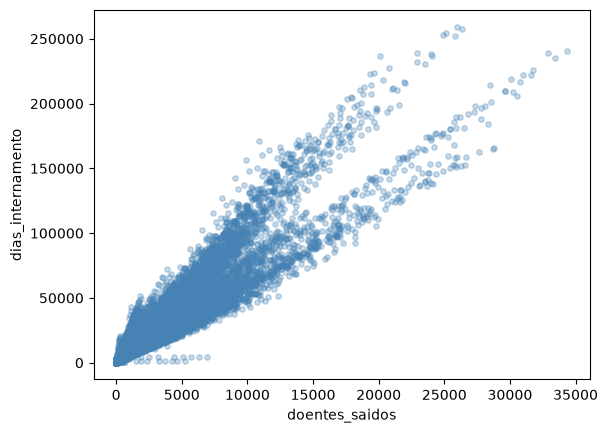

In [9]:

import matplotlib.pyplot as plt 

df.plot(

    kind="scatter",
    x="doentes_saidos",
    y="dias_internamento",
    alpha=0.3,          # transparência para revelar densidade
    s=15,               # pontos mais pequenos
    color="steelblue")

correlacao = df["doentes_saidos"].corr(df["dias_internamento"])
print(f"A correlação entre as duas varíaveis númericas é: {correlacao:.4f}")



A análise de correlação entre o número de doentes saídos e o total de dias de internamento revelou um coeficiente de Pearson de 0,93, indicando uma relação linear muito forte e positiva entre as duas variáveis, confirmada visualmente pelo diagrama de dispersão.
Este resultado reforça a importância de usar a demora média (e não o volume bruto de doentes ou dias) nas comparações por região e ao longo do tempo, uma vez que ambas as variáveis tendem a crescer juntas. 
Ainda assim, esta correlação tem um caráter em parte estrutural: mais doentes tratados implica naturalmente mais dias de internamento acumulados. Esta correlação não deve ser interpretada como uma descoberta inesperada, mas sim como confirmação da coerência dos dados.